# Regression Models

Decision Tree, Random Forest, XGBoost on engineered features.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    print('xgboost unavailable:', e)
    HAS_XGB = False

In [2]:
train = pd.read_csv('../reports/train_eng.csv', parse_dates=['created_at', 'actual_delivery_time'])
test  = pd.read_csv('../reports/test_eng.csv',  parse_dates=['created_at', 'actual_delivery_time'])
with open('../reports/feature_lists.json') as fh:
    feats = json.load(fh)
ENGINEERED_FEATURES = feats['engineered']
BASELINE_FEATURES   = feats['baseline']

y_train = train['delivery_duration'].values
y_test  = test['delivery_duration'].values
Xb_train, Xb_test = train[BASELINE_FEATURES], test[BASELINE_FEATURES]
Xe_train = train[ENGINEERED_FEATURES].copy()
Xe_test  = test[ENGINEERED_FEATURES].copy()

# Replace ±inf and fill residual NaN with train medians (handles log/ratio edge cases)
fill_vals = Xe_train.replace([np.inf, -np.inf], np.nan).median()
Xe_train  = Xe_train.replace([np.inf, -np.inf], np.nan).fillna(fill_vals)
Xe_test   = Xe_test.replace([np.inf, -np.inf], np.nan).fillna(fill_vals)

print('train:', train.shape, ' test:', test.shape)
print('features:', len(ENGINEERED_FEATURES))
print('NaN/inf in Xe_train:', Xe_train.isna().sum().sum(), '/', np.isinf(Xe_train.values).sum())

train: (157826, 36)  test: (39457, 36)
features: 29
NaN/inf in Xe_train: 0 / 0


In [3]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2':   r2_score(y_true, y_pred),
    }

os.makedirs('../models', exist_ok=True)
results = {}
preds_store = {}

def fit_eval(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    results[name] = regression_metrics(y_test, preds)
    preds_store[name] = preds
    joblib.dump(model, f'../models/{name}.joblib')
    m = results[name]
    print(f'{name:<32} MAE={m["MAE"]:.1f}  RMSE={m["RMSE"]:.1f}  R2={m["R2"]:.3f}')
    return model

## Task 1: Linear Regression (baseline + engineered)

In [4]:
fit_eval('Linear Regression (baseline)', LinearRegression(), Xb_train, Xb_test)
fit_eval('Linear Regression', LinearRegression(), Xe_train, Xe_test)

Linear Regression (baseline)     MAE=779.8  RMSE=1061.8  R2=0.093
Linear Regression                MAE=706.4  RMSE=961.8  R2=0.256


LinearRegression()

## Task 2: Decision Tree

In [5]:
fit_eval('Decision Tree', DecisionTreeRegressor(max_depth=10, random_state=0), Xe_train, Xe_test)

Decision Tree                    MAE=705.9  RMSE=986.8  R2=0.217


DecisionTreeRegressor(max_depth=10, random_state=0)

## Task 3: Random Forest

In [6]:
fit_eval('Random Forest',
         RandomForestRegressor(n_estimators=120, max_depth=18, n_jobs=-1, random_state=0),
         Xe_train, Xe_test)

Random Forest                    MAE=677.8  RMSE=934.1  R2=0.298


RandomForestRegressor(max_depth=18, n_estimators=120, n_jobs=-1, random_state=0)

## Task 4: XGBoost (with light hyperparameter choices)

Tuned: `max_depth=7`, `learning_rate=0.05`, `n_estimators=600`, `subsample=0.9`, `min_child_weight=5`.

In [7]:
if HAS_XGB:
    xgb_model = fit_eval(
        'XGBoost',
        XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=7,
            subsample=0.9, colsample_bytree=0.9, min_child_weight=5,
            tree_method='hist', n_jobs=-1, random_state=0,
        ),
        Xe_train, Xe_test,
    )
else:
    print('skipping XGBoost')

XGBoost                          MAE=652.2  RMSE=908.6  R2=0.336


## Task 5: Final model comparison

In [8]:
metrics_table = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']].round(2)
metrics_table.to_csv('../reports/model_metrics.csv')
metrics_table

,MAE,RMSE,R2
Linear Regression (baseline),779.83,1061.75,0.09
Linear Regression,706.41,961.79,0.26
Decision Tree,705.93,986.81,0.22
Random Forest,677.82,934.14,0.30
XGBoost,652.25,908.56,0.34


## Task 6: Feature importance

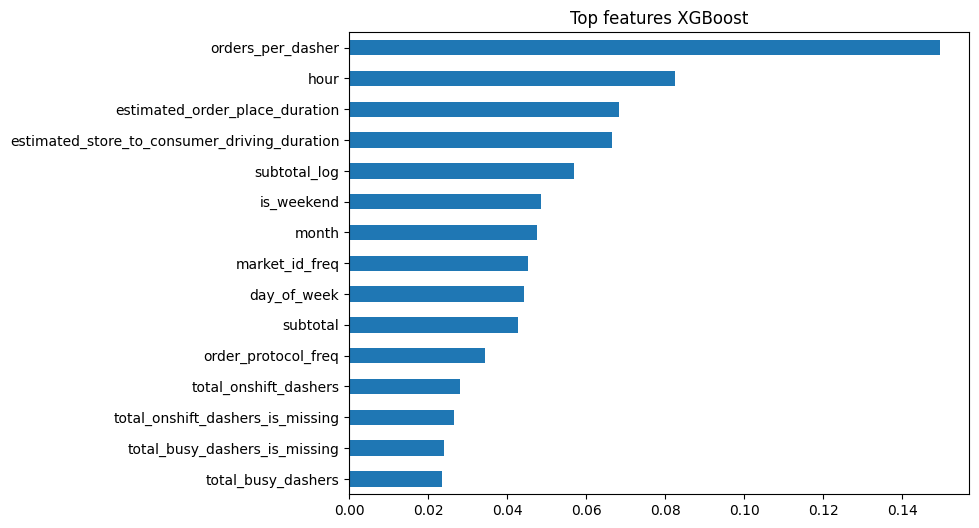

In [9]:
best_name = 'XGBoost' if HAS_XGB else 'Random Forest'
best_model = joblib.load(f'../models/{best_name}.joblib')
imp = pd.Series(best_model.feature_importances_, index=Xe_train.columns).sort_values(ascending=False)
imp.to_csv(f'../reports/feature_importance_{best_name}.csv')
imp.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis(); plt.title(f'Top features {best_name}'); plt.show()

In [10]:
test_out = test[['created_at', 'market_id', 'store_primary_category', 'delivery_duration']].copy()
for name, preds in preds_store.items():
    col = name.replace(' ', '_').replace('(', '').replace(')', '')
    test_out[f'pred_{col}'] = preds
test_out.to_csv('../reports/test_predictions.csv', index=False)
print('saved test_predictions.csv  shape:', test_out.shape)

saved test_predictions.csv  shape: (39457, 9)
